# Etap 4. Model Regresji Logistycznej prawdopobieństwa subsrybcji

In [2]:
import numpy as np
import pandas as pd
import sklearn

pd.set_option('display.max_columns', None)

customers_features = pd.read_csv(
    r'C:\Users\l\Documents\DATA_SCIENCE_KURS\PROJEKT_PREDYCJI_SUBSKRYBCJI_NEWSLETTERA\PROJEKT\b_oprzadek\data\customers_features.csv')

customers_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            1000 non-null   str    
 1   name                   1000 non-null   str    
 2   age                    1000 non-null   int64  
 3   state                  1000 non-null   str    
 4   signup_date            1000 non-null   str    
 5   email                  1000 non-null   str    
 6   phone_number           1000 non-null   int64  
 7   subscribe              1000 non-null   int64  
 8   customer_tenture_days  1000 non-null   int64  
 9   gender_Male            1000 non-null   bool   
 10  transaction_count      1000 non-null   int64  
 11  total_spent            1000 non-null   int64  
 12  avg_transaction_value  1000 non-null   float64
 13  total_quantity         1000 non-null   int64  
 14  avg_discount           1000 non-null   float64
 15  unique_products 

## Wybór zmiennych x i y

In [3]:
features = [
    "age",
    "gender_Male",
    "customer_tenture_days",
    "transaction_count",
    "total_spent",
    "unique_products",
    "avg_transaction_value",
    "total_quantity"
]

X = customers_features[features]

y = customers_features["subscribe"]

## Podział na zbiór testowy i treningowy

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Skalowanie zmiennych

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Budowa i trening modelu

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Ewaluacja modelu

=== Model metrics ===


,Metric,Score
0,Accuracy,0.9700
1,ROC AUC,0.9965



=== Classification report ===


,precision,recall,f1-score,support
0,0.9333,0.9655,0.9492,58.00
1,0.9857,0.9718,0.9787,142.00
accuracy,0.9700,0.9700,0.9700,0.97
macro avg,0.9595,0.9687,0.9639,200.00
weighted avg,0.9705,0.9700,0.9701,200.00


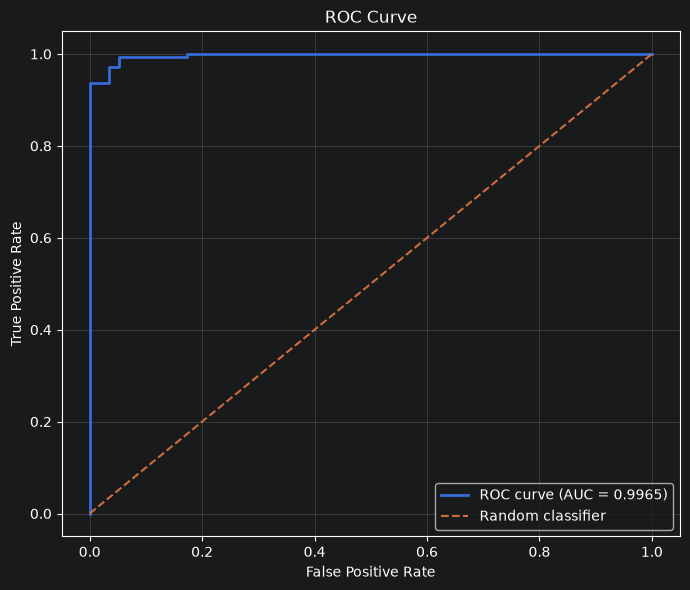

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Predykcje
y_pred = model.predict(X_test_scaled)
y_probability = model.predict_proba(X_test_scaled)[:, 1]

# =========================
# 1. Tabela z podstawowymi metrykami
# =========================

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "ROC AUC"],
    "Score": [accuracy, roc_auc]
})

metrics["Score"] = metrics["Score"].map(lambda x: f"{x:.4f}")

print("=== Model metrics ===")
display(metrics)


# =========================
# 2. Classification report jako tabela
# =========================

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).T

# Usuwamy zbędne wiersze, jeśli chcesz tylko klasy
report_df = report_df.round(4)

print("\n=== Classification report ===")
display(report_df)


# =========================
# 3. ROC AUC – wykres
# =========================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC curve (AUC = {roc_auc:.4f})",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Macież pomyłek (confusion matrix)

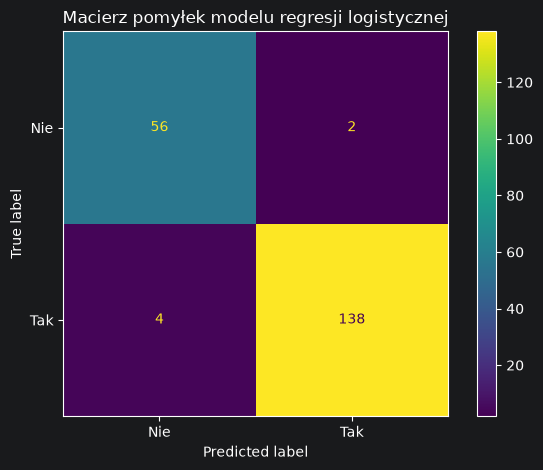

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Nie", "Tak"]
)

disp.plot()

plt.title(
    "Macierz pomyłek modelu regresji logistycznej"
)

plt.tight_layout()
plt.show()

## Wpływ zmiennych na predykcję

In [19]:
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    "coefficient",
    ascending=False
)

coefficients

,feature,coefficient
7,total_quantity,4.412399
6,avg_transaction_value,2.285044
4,total_spent,1.572905
2,customer_tenture_days,0.188202
1,gender_Male,-0.078006
0,age,-0.091200
3,transaction_count,-2.186448
5,unique_products,-2.186448


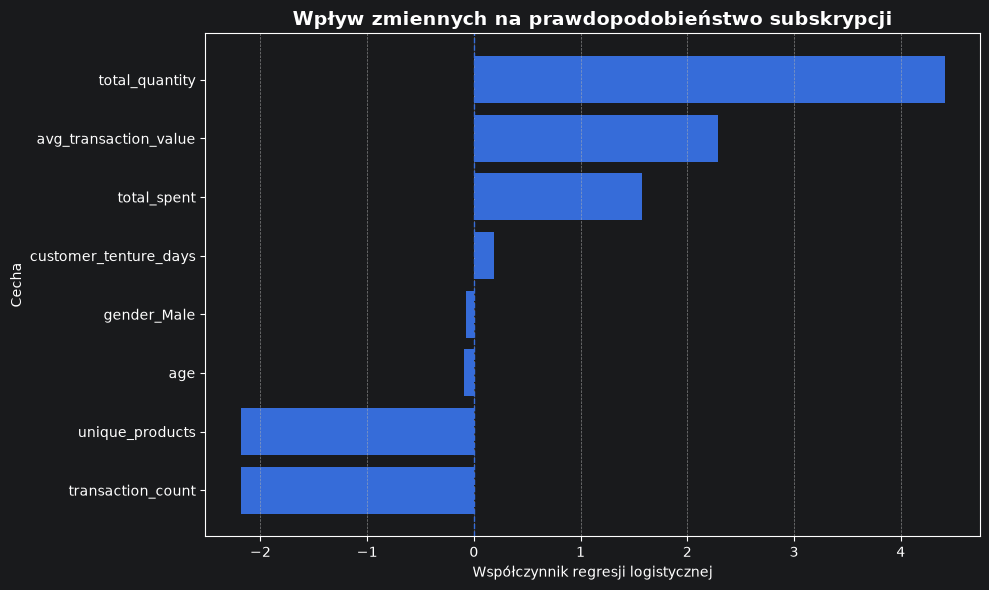

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

coefficients_sorted = coefficients.sort_values(
    "coefficient"
)

ax.barh(
    coefficients_sorted["feature"],
    coefficients_sorted["coefficient"]
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Wpływ zmiennych na prawdopodobieństwo subskrypcji",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Współczynnik regresji logistycznej"
)

ax.set_ylabel(
    "Cecha"
)

ax.grid(
    True,
    axis="x",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

## Interpretacja wyników

| Zmienna                   | Coefficient | Interpretacja                                                                                                                                                              |
| ------------------------- | ----------: | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **total_quantity**        |   **4.412** | Najsilniejszy dodatni wpływ. Wzrost liczby zakupionych produktów wiąże się ze znacznym wzrostem prawdopodobieństwa subskrypcji.                                            |
| **avg_transaction_value** |   **2.285** | Silny dodatni wpływ. Klienci dokonujący transakcji o wyższej średniej wartości są bardziej skłonni do subskrypcji.                                                         |
| **total_spent**           |   **1.573** | Dodatni wpływ. Wzrost całkowitej wartości zakupów zwiększa przewidywane prawdopodobieństwo subskrypcji.                                                                    |
| **customer_tenture_days** |   **0.188** | Niewielki dodatni wpływ. Dłuższy staż klienta wiąże się z nieznacznym wzrostem prawdopodobieństwa subskrypcji.                                                             |
| **gender_Male**           |  **-0.078** | Bardzo niewielki ujemny wpływ. W modelu płeć ma marginalne znaczenie w porównaniu z cechami zakupowymi.                                                                    |
| **age**                   |  **-0.091** | Bardzo niewielki ujemny wpływ. Wiek ma niewielkie znaczenie dla przewidywania subskrypcji.                                                                                 |
| **transaction_count**     |  **-2.186** | Silny ujemny wpływ. Przy pozostałych cechach utrzymanych na stałym poziomie większa liczba transakcji wiąże się ze spadkiem przewidywanego prawdopodobieństwa subskrypcji. |
| **unique_products**       |  **-2.186** | Silny ujemny wpływ. Przy pozostałych cechach bez zmian większa liczba unikalnych produktów wiąże się ze spadkiem przewidywanego prawdopodobieństwa subskrypcji.            |


## Wykresy zależności zmiennej na prawdopobieństwo dla pozostałych cech stałych (Ceteris Paribus - CP)

In [11]:
baseline = X.median()
baseline

age                            42.00
gender_Male                     0.00
customer_tenture_days         367.00
transaction_count               8.00
total_spent              48816500.00
unique_products                 8.00
avg_transaction_value     6969222.22
total_quantity                167.50
dtype: float64

In [12]:
def plot_cp(feature, X, model, scaler):

    # Zakres wartości cechy - 5-95 percentyl
    x_min = X[feature].quantile(0.05)
    x_max = X[feature].quantile(0.95)

    x_values = np.linspace(x_min, x_max, 100)

    # Typowy klient - wartości medianowe pozostałych cech
    baseline = X.median()

    # Tworzymy 100 identycznych klientów
    X_cp = pd.DataFrame(
        [baseline] * len(x_values),
        columns=X.columns
    )

    # Zmieniamy tylko badaną cechę
    X_cp[feature] = x_values

    # Skalowanie dokładnie tak samo jak przy trenowaniu modelu
    X_cp_scaled = scaler.transform(X_cp)

    # Predykcja prawdopodobieństwa subskrypcji
    probabilities = model.predict_proba(
        X_cp_scaled
    )[:, 1]

    # Wykres
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(
        x_values,
        probabilities * 100,
        linewidth=2
    )

    ax.set_title(
        f"Ceteris Paribus – {feature}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Prawdopodobieństwo subskrypcji [%]")

    # Dopasowanie osi Y do rzeczywistego zakresu predykcji
    probability_min = probabilities.min() * 100
    probability_max = probabilities.max() * 100

    margin = (probability_max - probability_min) * 0.1

    ax.set_ylim(
        max(0, probability_min - margin),
        min(100, probability_max + margin)
    )

    ax.grid(
        True,
        linestyle="--",
        alpha=0.7
    )

    plt.tight_layout()
    plt.show()

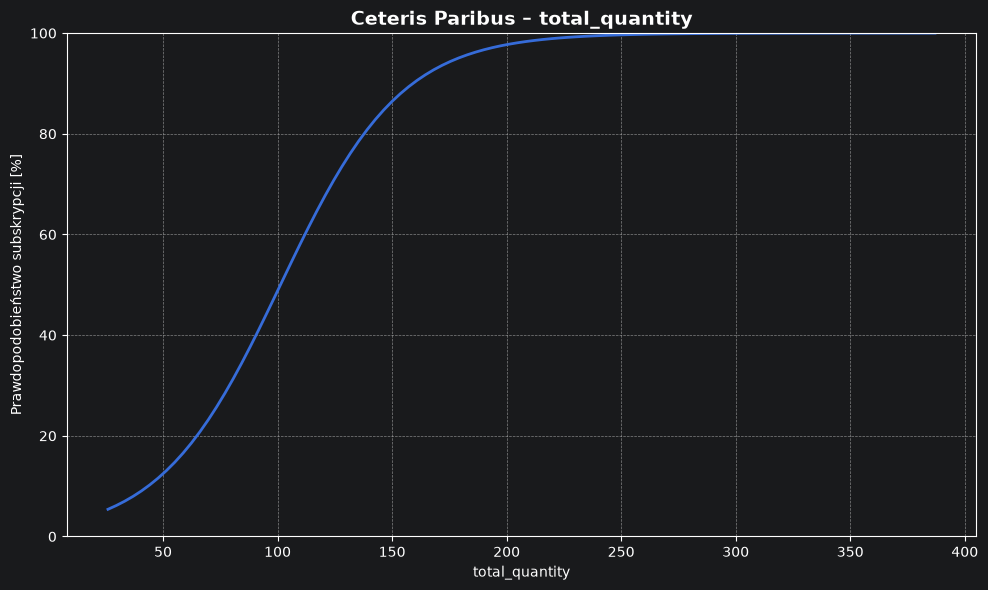

In [13]:
plot_cp(
    "total_quantity",
    X,
    model,
    scaler
)

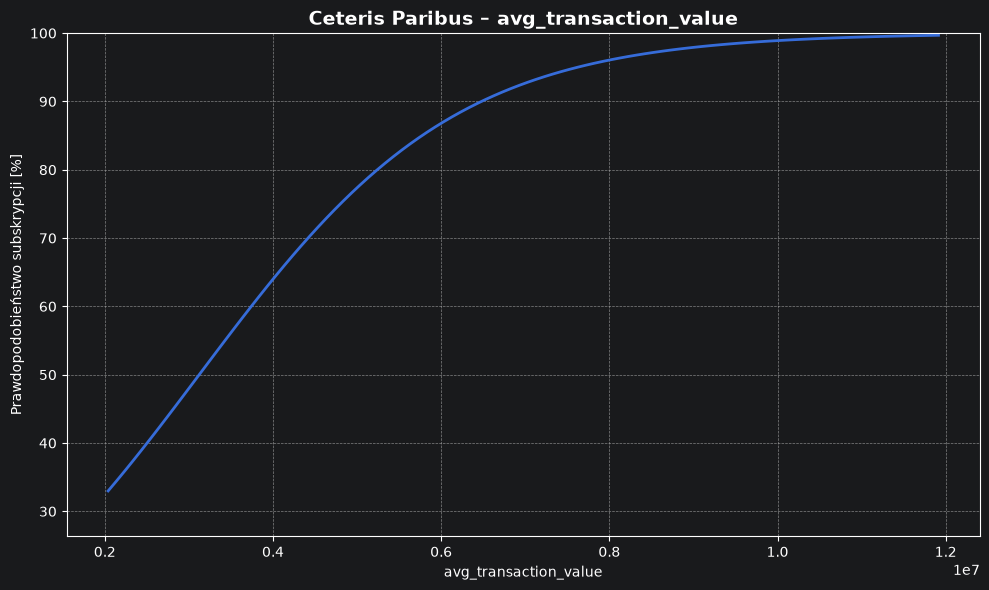

In [14]:
plot_cp(
    "avg_transaction_value",
    X,
    model,
    scaler
)

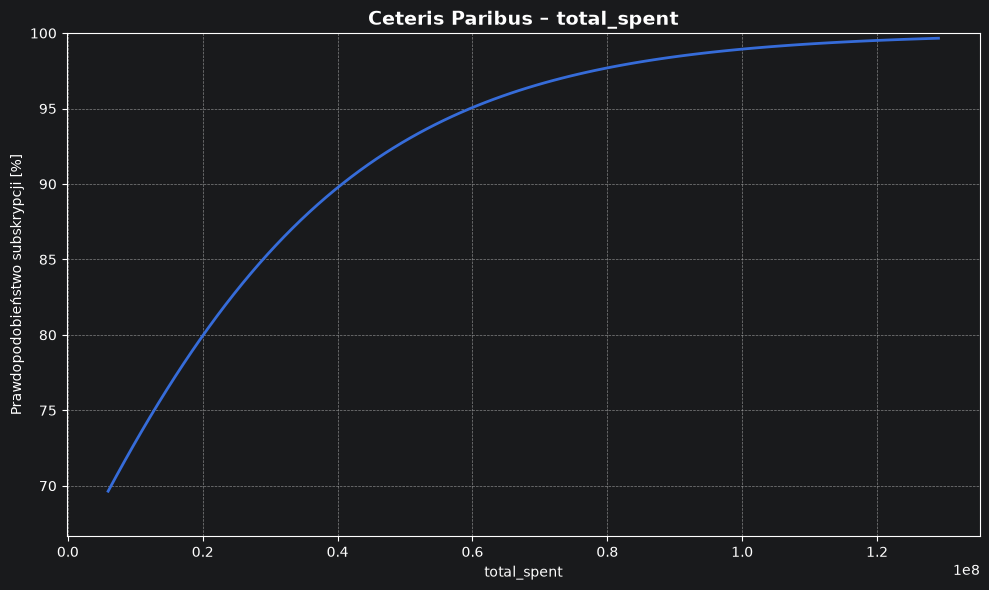

In [15]:
plot_cp(
    "total_spent",
    X,
    model,
    scaler
)

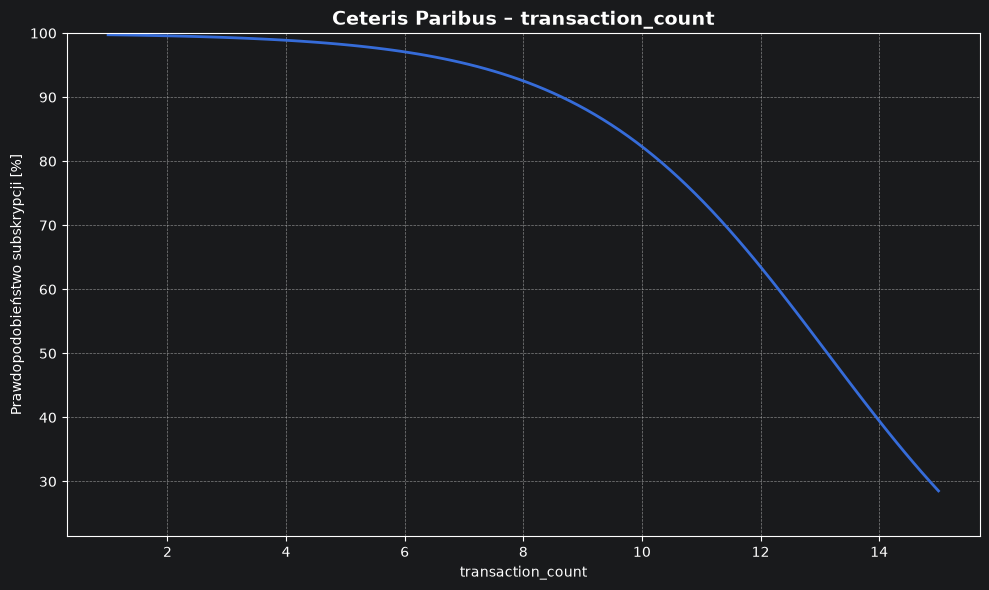

In [16]:
plot_cp(
    "transaction_count",
    X,
    model,
    scaler
)

## Zestawienie zmiennych

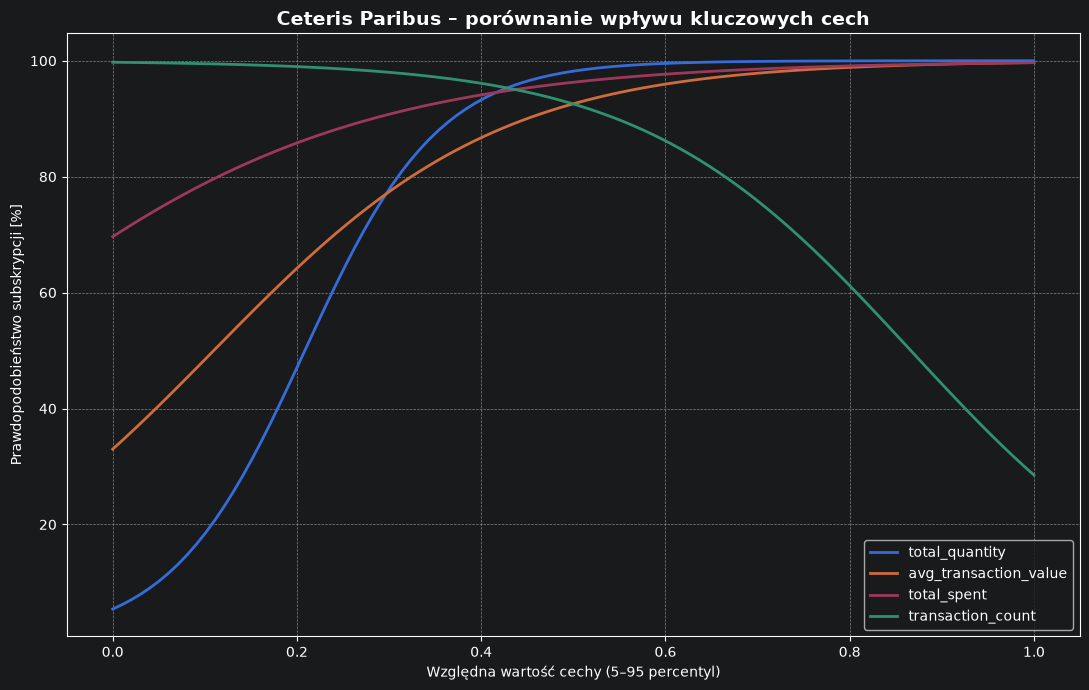

In [17]:
features_cp = [
    "total_quantity",
    "avg_transaction_value",
    "total_spent",
    "transaction_count"
]

fig, ax = plt.subplots(figsize=(11, 7))

for feature in features_cp:

    x_min = X[feature].quantile(0.05)
    x_max = X[feature].quantile(0.95)

    x_values = np.linspace(x_min, x_max, 100)

    baseline = X.median()

    X_cp = pd.DataFrame(
        [baseline] * len(x_values),
        columns=X.columns
    )

    X_cp[feature] = x_values

    X_cp_scaled = scaler.transform(X_cp)

    probabilities = model.predict_proba(
        X_cp_scaled
    )[:, 1]

    # Normalizacja osi X tylko do wizualizacji
    x_normalized = (
        x_values - x_min
    ) / (
        x_max - x_min
    )

    ax.plot(
        x_normalized,
        probabilities * 100,
        linewidth=2,
        label=feature
    )

ax.set_title(
    "Ceteris Paribus – porównanie wpływu kluczowych cech",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Względna wartość cechy (5–95 percentyl)"
)

ax.set_ylabel(
    "Prawdopodobieństwo subskrypcji [%]"
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.7
)

ax.legend()

plt.tight_layout()
plt.show()

## Podsumowanie modelu

W celu przewidywania prawdopodobieństwa subskrypcji zbudowano model regresji logistycznej. Do modelu wykorzystano osiem cech opisujących charakterystykę klienta oraz jego zachowania zakupowe. Dane podzielono na zbiór treningowy i testowy w proporcji 80/20, z zachowaniem proporcji klas, a zmienne zostały poddane standaryzacji.

Model osiągnął na zbiorze testowym 97% accuracy oraz ROC AUC na poziomie 0.9965, co wskazuje na bardzo dobrą zdolność rozróżniania klientów subskrybujących od niesubskrybujących. Dla klasy subskrybentów precision wyniosło 0.99, recall 0.97, a F1-score 0.98.

Analiza współczynników wykazała, że największy dodatni wpływ na predykcję mają total_quantity, avg_transaction_value oraz total_spent. Oznacza to, że model przypisuje większe prawdopodobieństwo subskrypcji klientom charakteryzującym się większą aktywnością zakupową i większą wartością zakupów. Z kolei transaction_count oraz unique_products posiadają silne współczynniki ujemne. Wpływ wieku, płci oraz stażu klienta jest zdecydowanie mniejszy.

Z punktu widzenia biznesowego model może zostać wykorzystany do identyfikacji klientów o wysokim prawdopodobieństwie subskrypcji. Zamiast traktować wszystkich klientów jednakowo, firma może kierować działania marketingowe przede wszystkim do klientów, dla których model przewiduje wysokie prawdopodobieństwo subskrypcji. Pozwala to wykorzystać dane dotyczące zachowań zakupowych do bardziej precyzyjnego targetowania działań marketingowych.

Analiza Ceteris Paribus pozwala dodatkowo zobrazować, jak zmiana poszczególnych cech wpływa na przewidywane prawdopodobieństwo subskrypcji przy pozostałych cechach utrzymanych na stałym poziomie. Dzięki temu wyniki modelu są łatwiejsze do interpretacji z perspektywy biznesowej.